In [1]:
!pip install xgboost

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

import matplotlib.pyplot as plt
import seaborn as sns

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
    --------------------------------------- 2.1/101.7 MB 11.6 MB/s eta 0:00:09
   - -------------------------------------- 4.7/101.7 MB 11.6 MB/s eta 0:00:09
   -- ------------------------------------- 5.2/101.7 MB 11.6 MB/s eta 0:00:09
   -- ------------------------------------- 7.3/101.7 MB 8.9 MB/s eta 0:00:11
   --- ------------------------------------ 8.4/101.7 MB 9.2 MB/s eta 0:00:11
   --- ------------------------------------ 9.7/101.7 MB 7.8 MB/s eta 0:00:12
   ---- ----------------------------------- 12.1/101.7 MB 8.4 MB/s eta 0:00:11
   ----- ---------------------------------- 14.4/101.7 MB 8.8 MB/s eta 0:00:10
   ------ --------------------------------- 16.8/101.7 MB 9.1 MB/s eta 0:00:10
   ------ --------------------------------- 16.8/101.7 MB 9.1 MB/s eta 0:00:10
   ------ --------------------------------- 17.6/101.7 MB 7.8 MB

ModuleNotFoundError: No module named 'pandas'

In [ ]:
import pandas as pd
from google.colab import drive

drive.mount('/content/drive')
file_path = '/content/drive/MyDrive/customer_purchase_data.csv'
df = pd.read_csv(file_path)
print("Shape:", df.shape)
df.head()

Mounted at /content/drive
Shape: (1500, 9)


,Age,Gender,AnnualIncome,NumberOfPurchases,ProductCategory,TimeSpentOnWebsite,LoyaltyProgram,DiscountsAvailed,PurchaseStatus
0,40,1,66120.267939,8,0,30.568601,0,5,1
1,20,1,23579.773583,4,2,38.240097,0,5,0
2,27,1,127821.306432,11,2,31.633212,1,0,1
3,24,1,137798.623120,19,3,46.167059,0,4,1
4,31,1,99300.964220,19,1,19.823592,0,0,1


In [ ]:
df.info()
print("\nMissing values:\n", df.isnull().sum())

print("\nUnique PurchaseStatus:", df['PurchaseStatus'].unique())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Age                 1500 non-null   int64  
 1   Gender              1500 non-null   int64  
 2   AnnualIncome        1500 non-null   float64
 3   NumberOfPurchases   1500 non-null   int64  
 4   ProductCategory     1500 non-null   int64  
 5   TimeSpentOnWebsite  1500 non-null   float64
 6   LoyaltyProgram      1500 non-null   int64  
 7   DiscountsAvailed    1500 non-null   int64  
 8   PurchaseStatus      1500 non-null   int64  
dtypes: float64(2), int64(7)
memory usage: 105.6 KB

Missing values:
 Age                   0
Gender                0
AnnualIncome          0
NumberOfPurchases     0
ProductCategory       0
TimeSpentOnWebsite    0
LoyaltyProgram        0
DiscountsAvailed      0
PurchaseStatus        0
dtype: int64

Unique PurchaseStatus: [1 0]


In [ ]:
# 🔥 ถ้าเป็นข้อความ → map
if df['PurchaseStatus'].dtype == 'object':
    df['PurchaseStatus'] = df['PurchaseStatus'].map({'No':0, 'Yes':1})

# ลบ NaN (กัน data หาย)
df = df.dropna()

print("After cleaning:", df.shape)

After cleaning: (1500, 9)


In [ ]:
X = df.drop('PurchaseStatus', axis=1)
y = df['PurchaseStatus']

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (1500, 8)
y shape: (1500,)


In [ ]:
categorical_cols = ['Gender', 'ProductCategory', 'LoyaltyProgram']

X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

print("After encoding:", X.shape)

After encoding: (1500, 11)


In [ ]:
if X.shape[0] == 0:
    raise ValueError("Data is empty ก่อน split")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (1200, 11)
Test: (300, 11)


In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
models = {
    "Logistic Regression": LogisticRegression(),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "XGBoost": XGBClassifier(eval_metric='logloss')
}

results = []

for name, model in models.items():

    if name == "Logistic Regression":
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    results.append([name, acc, prec, rec, f1])

    print(f"\n=== {name} ===")
    print(classification_report(y_test, y_pred))


=== Logistic Regression ===
              precision    recall  f1-score   support

           0       0.82      0.92      0.87       172
           1       0.88      0.72      0.79       128

    accuracy                           0.84       300
   macro avg       0.85      0.82      0.83       300
weighted avg       0.84      0.84      0.83       300


=== Random Forest ===
              precision    recall  f1-score   support

           0       0.93      0.99      0.96       172
           1       0.99      0.90      0.94       128

    accuracy                           0.95       300
   macro avg       0.96      0.95      0.95       300
weighted avg       0.96      0.95      0.95       300


=== XGBoost ===
              precision    recall  f1-score   support

           0       0.92      0.99      0.96       172
           1       0.99      0.88      0.93       128

    accuracy                           0.95       300
   macro avg       0.96      0.94      0.94       300
weigh

In [ ]:
results_df = pd.DataFrame(results, columns=['Model','Accuracy','Precision','Recall','F1'])
results_df

,Model,Accuracy,Precision,Recall,F1
0,Logistic Regression,0.836667,0.876190,0.718750,0.789700
1,Random Forest,0.953333,0.991379,0.898438,0.942623
2,XGBoost,0.946667,0.991228,0.882812,0.933884


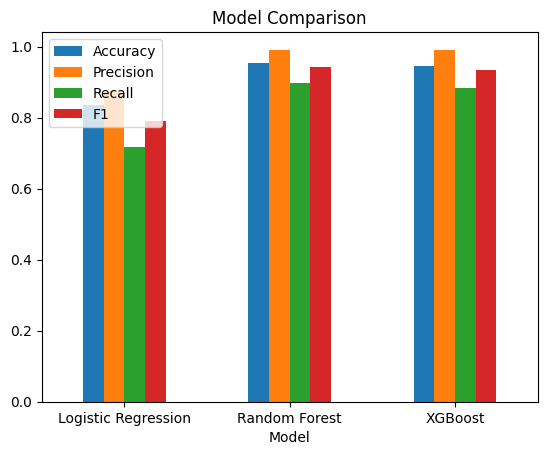

In [ ]:
results_df.set_index('Model').plot(kind='bar')
plt.title("Model Comparison")
plt.xticks(rotation=0)
plt.show()

In [ ]:
rf = models["Random Forest"]

feat_imp = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
}).sort_values(by='Importance', ascending=False)

feat_imp.head(10)

,Feature,Importance
3,TimeSpentOnWebsite,0.204702
0,Age,0.184040
4,DiscountsAvailed,0.159255
1,AnnualIncome,0.156253
2,NumberOfPurchases,0.140612
10,LoyaltyProgram_1,0.098927
5,Gender_1,0.015169
7,ProductCategory_2,0.011886
9,ProductCategory_4,0.010507
6,ProductCategory_1,0.010237


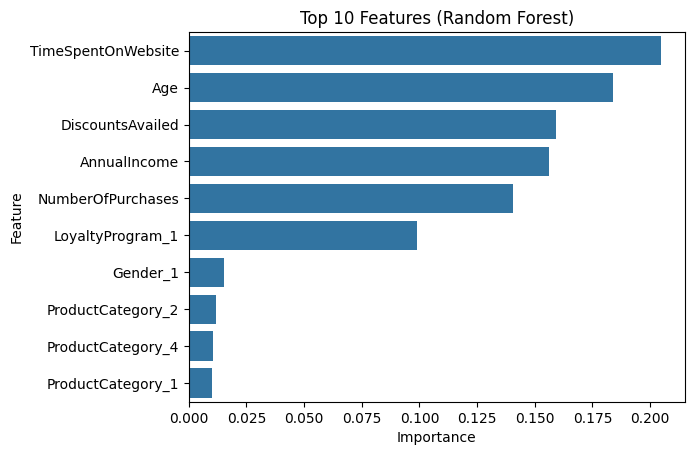

In [ ]:
sns.barplot(data=feat_imp.head(10), x='Importance', y='Feature')
plt.title("Top 10 Features (Random Forest)")
plt.show()

In [ ]:
lr = models["Logistic Regression"]

coef = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': lr.coef_[0]
}).sort_values(by='Coefficient', ascending=False)

coef.head(10)

,Feature,Coefficient
4,DiscountsAvailed,1.159199
10,LoyaltyProgram_1,1.127980
3,TimeSpentOnWebsite,1.031944
1,AnnualIncome,0.728014
2,NumberOfPurchases,0.604421
6,ProductCategory_1,0.045390
5,Gender_1,0.017132
7,ProductCategory_2,-0.060502
8,ProductCategory_3,-0.063240
9,ProductCategory_4,-0.126165


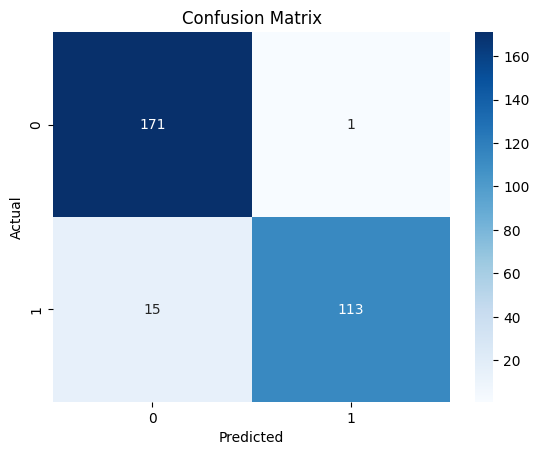

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()